# Individual homework project 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("data/customers.csv")
transactions = pd.read_csv("data/transactions.csv")
sessions = pd.read_csv("data/web_sessions.csv")
campaigns = pd.read_csv("data/campaign_touchpoints.csv")

### Specific questions

In [3]:
customers.head()

,customer_id,age,gender,country,acquisition_channel,signup_date,customer_status,loyalty_tier,campaign_id,last_active_date
0,1,56.0,Other,Germany,referral,2019-07-21,one_time,none,183,2021-04-06
1,2,38.0,Other,Netherlands,email,2022-03-04,churned,none,548,2024-11-27
2,3,28.0,Other,Australia,referral,2024-05-21,repeat,bronze,37,2025-01-07
3,4,19.0,Female,Australia,paid_search,2022-06-28,repeat,bronze,14,2024-03-20
4,5,38.0,Female,Australia,referral,2024-07-17,one_time,none,635,2024-11-12


In [47]:
transactions.head()

,transaction_id,customer_id,product_category,purchase_value,discount_used,purchase_date,is_refunded,refund_date,refund_reason
0,1,8141,home,380.95,0,2023-09-05,0,NaN,NaN
1,2,1297,fashion,67.08,0,2019-08-07,0,NaN,NaN
2,3,7930,toys,43.37,1,2020-02-07,1,1.581898e+18,late_delivery
3,4,2426,electronics,1191.45,0,2020-10-02,0,NaN,NaN
4,5,6614,fashion,112.21,0,2023-09-15,0,NaN,NaN


In [ ]:
sessions.head()

,session_id,customer_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted,bounce,cart_additions,checkout_started,exit_page,browser,is_logged_in
0,1,9716,8,271.238207,desktop,organic,2022-06-18,0,0,0,0,homepage,Chrome,1
1,2,4617,5,257.386842,mobile,social,2020-07-03,0,0,3,1,checkout,Chrome,1
2,3,1506,4,289.679888,tablet,paid,2020-12-12,0,0,3,1,cart,Chrome,1
3,4,3869,5,146.543376,mobile,direct,2023-09-12,0,1,2,1,homepage,Chrome,1
4,5,6245,3,339.228209,mobile,email,2019-04-02,0,0,2,1,product,Safari,1


Q1. What is the average purchase value for customers from Spain?

In [5]:
merged = transactions.merge(customers, on="customer_id")
merged[merged["country"] == "Spain"]["purchase_value"].mean()

np.float64(230.95889872521244)

In [6]:
merged.groupby(["country"])["purchase_value"].mean()

country
Australia      232.416014
Canada         232.825274
France         237.192271
Germany        239.028571
Netherlands    237.213789
Spain          230.958899
UK             234.835997
US             234.809181
Name: purchase_value, dtype: float64

In [ ]:
# how I did in University
spaincustomers = customers[customers["country"] == "Spain"]
spaintransactions = transactions[transactions["customer_id"].isin(spaincustomers["customer_id"])]
spaintransactions["purchase_value"].mean()

np.float64(230.95889872521244)

In [ ]:
# The average purchase value for customers from Spain is approximately 230.96.

Q2. What is the minimum purchase value for customers from Germany?

In [62]:
merged[merged["country"] == "Germany"]["purchase_value"].min()

np.float64(10.01)

In [14]:
merged.groupby(["country"])["purchase_value"].min()

country
Australia      10.06
Canada         10.03
France         10.14
Germany        10.01
Netherlands    10.08
Spain          10.04
UK             10.01
US             10.17
Name: purchase_value, dtype: float64

In [ ]:
# how I did in University
gercustomers = customers[customers["country"] == "Germany"]
gertransactions = transactions[transactions["customer_id"].isin(gercustomers["customer_id"])]
gertransactions["purchase_value"].min()

np.float64(10.01)

In [ ]:
# The minimum purchase value from customers from Germany is 10.01.

Q3. How much did males spend on buying products in the Sports category?

In [64]:
merged[(merged["gender"] == "Male") &(merged["product_category"] == "sports")]["purchase_value"].sum()

np.float64(404877.87)

In [15]:
merged.groupby(["gender", "product_category"])["purchase_value"].sum()

gender  product_category
Female  beauty               414141.94
        electronics         1723282.56
        fashion              254664.80
        home                 681790.65
        sports               403034.06
        toys                 117134.59
Male    beauty               419027.23
        electronics         1685148.33
        fashion              254478.84
        home                 681384.33
        sports               404877.87
        toys                 109659.68
Other   beauty               385749.06
        electronics         1611757.24
        fashion              250822.47
        home                 659422.40
        sports               402969.77
        toys                 110166.44
Name: purchase_value, dtype: float64

In [ ]:
# how I did in University
malecustomers = customers[customers["gender"] == "Male"]
maletransactions = transactions[transactions["customer_id"].isin(malecustomers["customer_id"])]
malesportstransactions = maletransactions[maletransactions["product_category"] == "sports"]
malesportstransactions["purchase_value"].sum()

np.float64(404877.87)

In [ ]:
#Males spent 404,877.87 on products in the Sports category.

Q4. What is the average age of female customers from Canada?

In [8]:
customers[customers["gender"] == "Female"].groupby("country")["age"].mean()["Canada"]

np.float64(42.9168765743073)

In [7]:
merged.groupby(["gender", "country"])["age"].mean()

gender  country    
Female  Australia      43.916448
        Canada         43.065352
        France         42.854217
        Germany        44.577966
        Netherlands    44.993594
        Spain          43.267156
        UK             41.795679
        US             43.627907
Male    Australia      44.274164
        Canada         42.962117
        France         42.512882
        Germany        43.781871
        Netherlands    43.081531
        Spain          43.314573
        UK             43.792193
        US             43.131680
Other   Australia      45.708082
        Canada         43.565318
        France         44.552960
        Germany        42.446078
        Netherlands    42.978335
        Spain          43.436433
        UK             43.626021
        US             43.793358
Name: age, dtype: float64

In [65]:
customers[(customers["gender"] == "Female") &(customers["country"] == "Canada")]["age"].mean()

np.float64(42.9168765743073)

In [ ]:
# how I did in University (2 steps slower)
femalecanada = customers[(customers["gender"] == "Female") &(customers["country"] == "Canada")]
femalecanada["age"].mean()

np.float64(42.9168765743073)

In [ ]:
#The average age of female customers from Canada is approximately 42.92 years.

Q5. How much does an average male customer from the UK spend?

In [66]:
merged[(merged["gender"] == "Male") & (merged["country"] == "UK")]["purchase_value"].mean()

np.float64(234.48157309322036)

In [9]:
merged.groupby(["gender", "country"])["purchase_value"].mean()

gender  country    
Female  Australia      234.410373
        Canada         237.011016
        France         238.974468
        Germany        239.134334
        Netherlands    236.623172
        Spain          231.818762
        UK             234.585814
        US             235.375486
Male    Australia      234.091933
        Canada         231.102896
        France         237.544524
        Germany        238.995246
        Netherlands    237.057669
        Spain          229.470991
        UK             234.481573
        US             235.876442
Other   Australia      228.469299
        Canada         230.319397
        France         235.241114
        Germany        238.934179
        Netherlands    237.909207
        Spain          231.539906
        UK             235.384270
        US             233.078291
Name: purchase_value, dtype: float64

In [ ]:
# how I did in University
ukmalecustomers = customers[(customers["gender"] == "Male") &(customers["country"] == "UK")]
ukmaletransactions = transactions[transactions["customer_id"].isin(ukmalecustomers["customer_id"])]
ukmaletransactions["purchase_value"].mean()

np.float64(234.48157309322036)

In [ ]:
#The average male customer from the UK spends approximately 234.48.

Q6. What is the maximum purchase value for females in the Toys category?

In [ ]:
merged[(merged["gender"] == "Female") &(merged["product_category"] == "toys")]["purchase_value"].max()

np.float64(79.99)

In [11]:
merged.groupby(["gender", "product_category"])["purchase_value"].max()

gender  product_category
Female  beauty               299.69
        electronics         1199.80
        fashion              179.91
        home                 499.95
        sports               299.95
        toys                  79.99
Male    beauty               299.99
        electronics         1199.89
        fashion              179.94
        home                 499.31
        sports               299.97
        toys                  79.98
Other   beauty               299.96
        electronics         1199.80
        fashion              179.83
        home                 499.57
        sports               299.87
        toys                  79.94
Name: purchase_value, dtype: float64

In [ ]:
# how I did in University
femalecustomers = customers[customers["gender"] == "Female"]
femaletransactions = transactions[transactions["customer_id"].isin(femalecustomers["customer_id"])]
femaletoystransactions = femaletransactions[femaletransactions["product_category"] == "toys"]
femaletoystransactions["purchase_value"].max()

np.float64(79.99)

In [ ]:
# The maximum purchase value for female customers in the Toys category is 79.99.

Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [71]:
sessions.head(10)

,session_id,customer_id,pages_viewed,time_on_site,device_type,traffic_source,session_date,converted,bounce,cart_additions,checkout_started,exit_page,browser,is_logged_in
0,1,9716,8,271.238207,desktop,organic,2022-06-18,0,0,0,0,homepage,Chrome,1
1,2,4617,5,257.386842,mobile,social,2020-07-03,0,0,3,1,checkout,Chrome,1
2,3,1506,4,289.679888,tablet,paid,2020-12-12,0,0,3,1,cart,Chrome,1
3,4,3869,5,146.543376,mobile,direct,2023-09-12,0,1,2,1,homepage,Chrome,1
4,5,6245,3,339.228209,mobile,email,2019-04-02,0,0,2,1,product,Safari,1
5,6,7578,8,200.057610,tablet,paid,2022-07-22,0,0,2,0,product,Firefox,1
6,7,6521,8,17.707507,tablet,email,2024-01-14,1,1,1,1,homepage,Chrome,0
7,8,7338,2,328.627521,desktop,email,2024-06-27,0,0,3,1,homepage,Edge,1
8,9,2187,3,51.638969,tablet,direct,2019-10-30,0,0,2,1,cart,Chrome,1
9,10,2675,5,303.360671,mobile,direct,2020-02-04,0,0,2,1,checkout,Chrome,0


In [17]:
sessions.groupby(["converted"])["pages_viewed"].mean()

converted
0    4.885475
1    5.728620
Name: pages_viewed, dtype: float64

In [68]:
sessions[sessions["converted"] == 1]["pages_viewed"].mean()

np.float64(5.728619675345898)

In [ ]:
# how I did in University (2 steps slower)
convertedsessions = sessions[sessions["converted"] == 1]
convertedsessions["pages_viewed"].mean()

np.float64(5.728619675345898)

In [ ]:
#The average number of pages viewed for customers who made a purchase (converted) is approximately 5.73 pages.

Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [72]:
sessions.groupby("converted")["time_on_site"].mean()

converted
0    299.238547
1    311.194837
Name: time_on_site, dtype: float64

In [ ]:
# how I did in University
purchasing = sessions[sessions["converted"] == 1]
nonpurchasing = sessions[sessions["converted"] == 0]
purchasing["time_on_site"].mean(), nonpurchasing["time_on_site"].mean()

(np.float64(311.19483699910387), np.float64(299.238547290892))

In [ ]:
#The average time spent on the site is approximately 311.19 for purchasing customers and 299.24 for non-purchasing customers.

### Visualisation tasks

Q9. Plot purchasing value across years.

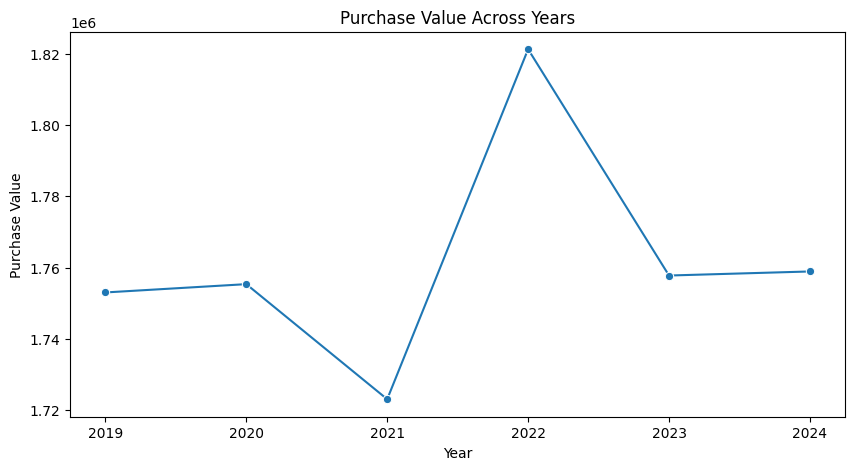

In [51]:
transactions["purchase_date"] = pd.to_datetime(transactions["purchase_date"])
yearly = transactions.groupby(transactions["purchase_date"].dt.year)["purchase_value"].sum()
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly.index, y=yearly.values, marker="o")
plt.title("Purchase Value Across Years")
plt.xlabel("Year")
plt.ylabel("Purchase Value")
plt.show()

Q10. Plot purchasing value across product categories.

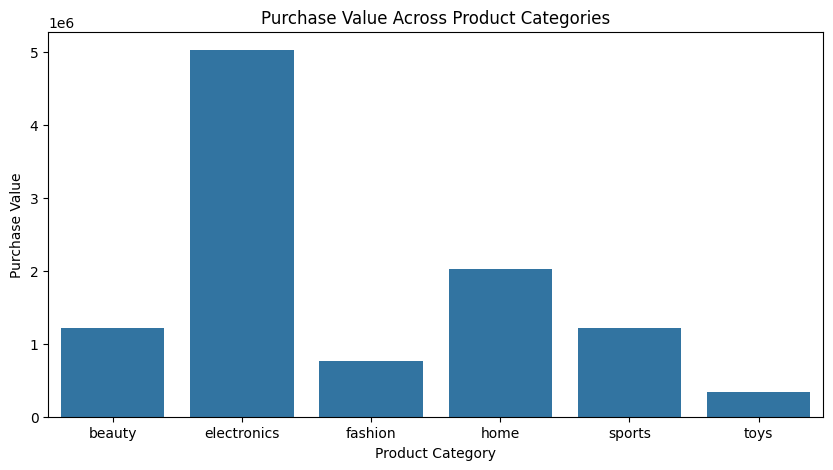

In [55]:
categorypurchase = transactions.groupby("product_category")["purchase_value"].sum()
plt.figure(figsize=(10,5))
sns.barplot(x=categorypurchase.index, y=categorypurchase.values)
plt.title("Purchase Value Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Purchase Value")
plt.show()

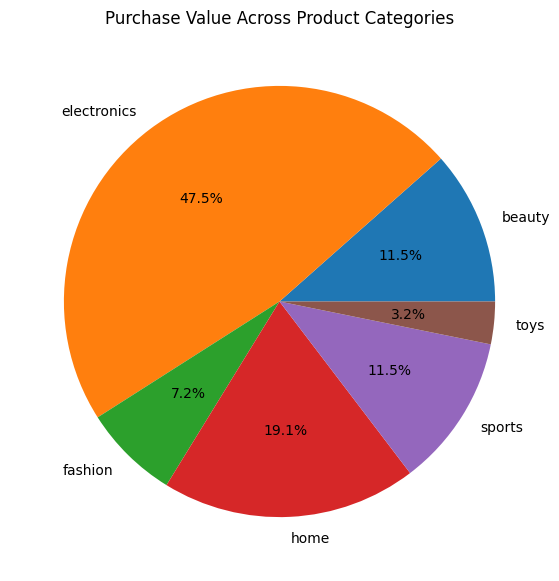

In [56]:
categorypurchase = transactions.groupby("product_category")["purchase_value"].sum()
plt.figure(figsize=(7,7))
plt.pie(categorypurchase.values,labels=categorypurchase.index,autopct="%1.1f%%")
plt.title("Purchase Value Across Product Categories")
plt.show()

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

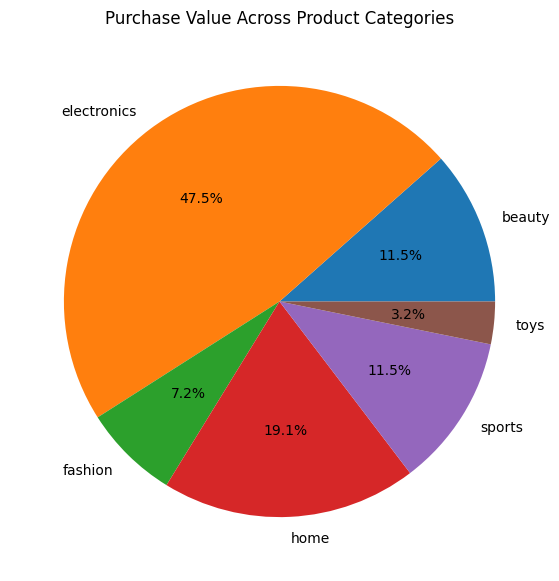

In [58]:
categorypurchase = transactions.groupby("product_category")["purchase_value"].sum()
plt.figure(figsize=(7,7))
plt.pie(categorypurchase.values,labels=categorypurchase.index,autopct="%1.1f%%")
plt.title("Purchase Value Across Product Categories")
plt.show()

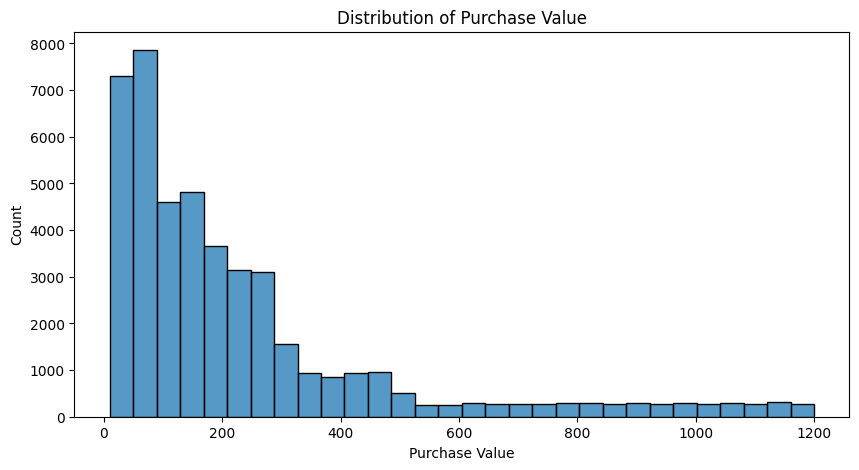

In [59]:
plt.figure(figsize=(10,5))
sns.histplot(transactions["purchase_value"], bins=30)
plt.title("Distribution of Purchase Value")
plt.xlabel("Purchase Value")
plt.show()

In [ ]:
# Three patterns I noticed in the data:
# 1. Most purchase values are below $100, while only a small number of
#    transactions have very high values.
# 2. The purchase value distribution has a long tail, with some transactions
#    reaching around $1,200.
# 3. Electronics represents the largest share of total purchase value,
#    followed by Home, Beauty and Sports.

# Five insights:
# 1. Customers generally make smaller purchases rather than spending large
#    amounts in a single transaction.
# 2. A small number of high-value transactions could have a noticeable impact
#    on the overall spending.
# 3. Electronics seems to be the most important category in terms of spending.
# 4. The business could focus more on Electronics, since it represents a large
#    part of the total purchase value.
# 5. Toys and Fashion have a much smaller contribution to total spending,
# which may suggest lower demand or lower-value purchases in these categories.